In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving used_car_price_dataset.xlsx to used_car_price_dataset.xlsx


In [3]:
df = pd.read_excel("used_car_price_dataset.xlsx")

df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,Brand,Model,Year,Mileage,Fuel_Type,Transmission,Price
1,NaN,Toyota,Kijang Innova,2025,2000,Diesel,Automatic,445000000
2,NaN,Toyota,Kijang Innova,2024,8000,Diesel,Automatic,425000000
3,NaN,Toyota,Kijang Innova,2023,15000,Diesel,Automatic,405000000
4,NaN,Toyota,Kijang Innova,2022,18000,Diesel,Automatic,395000000


In [4]:
import pandas as pd

df = pd.read_excel(
    "used_car_price_dataset.xlsx",
    header=1
)

df.head()

,Unnamed: 0,Brand,Model,Year,Mileage,Fuel_Type,Transmission,Price
0,NaN,Toyota,Kijang Innova,2025,2000,Diesel,Automatic,445000000
1,NaN,Toyota,Kijang Innova,2024,8000,Diesel,Automatic,425000000
2,NaN,Toyota,Kijang Innova,2023,15000,Diesel,Automatic,405000000
3,NaN,Toyota,Kijang Innova,2022,18000,Diesel,Automatic,395000000
4,NaN,Toyota,Kijang Innova,2021,30000,Diesel,Automatic,365000000


In [5]:
df = pd.read_excel(
    "used_car_price_dataset.xlsx",
    skiprows=1
)

df.head()


,Unnamed: 0,Brand,Model,Year,Mileage,Fuel_Type,Transmission,Price
0,NaN,Toyota,Kijang Innova,2025,2000,Diesel,Automatic,445000000
1,NaN,Toyota,Kijang Innova,2024,8000,Diesel,Automatic,425000000
2,NaN,Toyota,Kijang Innova,2023,15000,Diesel,Automatic,405000000
3,NaN,Toyota,Kijang Innova,2022,18000,Diesel,Automatic,395000000
4,NaN,Toyota,Kijang Innova,2021,30000,Diesel,Automatic,365000000


In [7]:
df = df.drop(columns=["Unnamed: 0"])

df.head()

,Brand,Model,Year,Mileage,Fuel_Type,Transmission,Price
0,Toyota,Kijang Innova,2025,2000,Diesel,Automatic,445000000
1,Toyota,Kijang Innova,2024,8000,Diesel,Automatic,425000000
2,Toyota,Kijang Innova,2023,15000,Diesel,Automatic,405000000
3,Toyota,Kijang Innova,2022,18000,Diesel,Automatic,395000000
4,Toyota,Kijang Innova,2021,30000,Diesel,Automatic,365000000


In [8]:
print(df.columns)

Index(['Brand', 'Model', 'Year', 'Mileage', 'Fuel_Type', 'Transmission',
       'Price'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Brand         21 non-null     object
 1   Model         21 non-null     object
 2   Year          21 non-null     int64 
 3   Mileage       21 non-null     int64 
 4   Fuel_Type     21 non-null     object
 5   Transmission  21 non-null     object
 6   Price         21 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 1.3+ KB


In [10]:
from sklearn.preprocessing import LabelEncoder

le_brand = LabelEncoder()
le_model = LabelEncoder()
le_fuel = LabelEncoder()
le_trans = LabelEncoder()

df["Brand"] = le_brand.fit_transform(df["Brand"])
df["Model"] = le_model.fit_transform(df["Model"])
df["Fuel_Type"] = le_fuel.fit_transform(df["Fuel_Type"])
df["Transmission"] = le_trans.fit_transform(df["Transmission"])

df.head()

,Brand,Model,Year,Mileage,Fuel_Type,Transmission,Price
0,1,2,2025,2000,1,0,445000000
1,1,2,2024,8000,1,0,425000000
2,1,2,2023,15000,1,0,405000000
3,1,2,2022,18000,1,0,395000000
4,1,2,2021,30000,1,0,365000000


In [11]:
X = df.drop("Price", axis=1)
y = df["Price"]

print(X.head())

   Brand  Model  Year  Mileage  Fuel_Type  Transmission
0      1      2  2025     2000          1             0
1      1      2  2024     8000          1             0
2      1      2  2023    15000          1             0
3      1      2  2022    18000          1             0
4      1      2  2021    30000          1             0


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Training :", len(X_train))
print("Data Testing :", len(X_test))

Data Training : 16
Data Testing : 5


In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model berhasil dilatih")

Model berhasil dilatih


In [6]:
print(df.columns)

Index(['Unnamed: 0', 'Brand', 'Model', 'Year', 'Mileage', 'Fuel_Type',
       'Transmission', 'Price'],
      dtype='object')


In [15]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("R2 Score :", r2)

MAE : 52200000.0
R2 Score : 0.5608647502356268


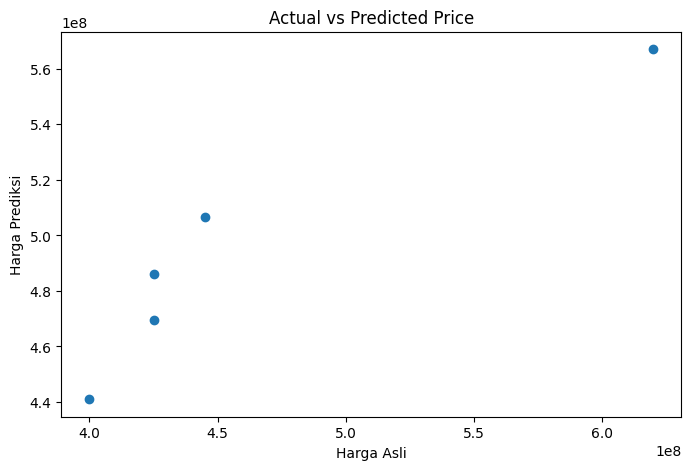

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Harga Asli")
plt.ylabel("Harga Prediksi")
plt.title("Actual vs Predicted Price")

plt.show()

In [17]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("R2 Score :", r2)

MAE : 52200000.0
R2 Score : 0.5608647502356268


In [14]:
y_pred = model.predict(X_test)

print(y_pred)

[5.0655e+08 4.4100e+08 4.6940e+08 4.8610e+08 5.6705e+08]
